# Cart-Pole RL Agent Training
**Deep Q-Network (DQN) on OpenAI Gymnasium's CartPole-v1**

**Name:** Tanay Singh  
**Registration No:** 23BCE11211  
**Environment:** [CartPole-v1 — Gymnasium](https://gymnasium.farama.org/environments/classic_control/cart_pole/)

---
## Objective
Train a reinforcement learning agent to **balance a pole upright on a moving cart** for as long as possible using a **Deep Q-Network (DQN)**.

### Environment
- **State (4 continuous values):** cart position, cart velocity, pole angle, pole angular velocity
- **Actions (2 discrete):** push cart left (0) or right (1)
- **Reward:** +1 for every timestep the pole stays upright
- **Episode ends** when the pole falls, cart moves off-screen, or 500 steps are reached
- **Solved** when the agent averages ≥475 reward over 100 consecutive episodes

## Imports

In [1]:
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
import seaborn as sns

import gymnasium as gym
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

sns.set_style('whitegrid')
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

print('TensorFlow  :', tf.__version__)
print('Gymnasium   :', gym.__version__)

TensorFlow  : 2.21.0
Gymnasium   : 1.3.0


## Task 1: Environment Setup

In [2]:
env = gym.make('CartPole-v1')
state_size  = int(env.observation_space.shape[0])
action_size = int(env.action_space.n)

print(f'State  size : {state_size} (cart_pos, cart_vel, pole_angle, pole_ang_vel)')
print(f'Action size : {action_size} (0 = push left, 1 = push right)')
print(f'Max episode length: 500 steps')

# Reset environment and inspect an example state
state, _ = env.reset(seed=42)
print(f'\nSample state: {state}')

State  size : 4 (cart_pos, cart_vel, pole_angle, pole_ang_vel)
Action size : 2 (0 = push left, 1 = push right)
Max episode length: 500 steps

Sample state: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]


## Task 2: DQN Agent

Standard DQN with:
- **Q-network:** 2 hidden layers (24 units each, ReLU) → linear output for 2 actions
- **Experience replay:** buffer of past transitions, sampled in mini-batches to break temporal correlation
- **Epsilon-greedy exploration:** starts at 1.0 (fully random), decays to 0.01
- **Target network** omitted for simplicity — vanilla DQN with a single network is enough to solve CartPole

In [3]:
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95           # discount factor
        self.epsilon = 1.0          # exploration rate
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.model = self._build_model()

    def _build_model(self):
        model = Sequential([
            tf.keras.Input(shape=(self.state_size,)),
            Dense(24, activation='relu'),
            Dense(24, activation='relu'),
            Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        # epsilon-greedy: random action with prob epsilon, else greedy Q
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        q_values = self.model(state, training=False).numpy()
        return int(np.argmax(q_values[0]))

    def replay(self, batch_size):
        # Sample a random minibatch of transitions and do one gradient step
        if len(self.memory) < batch_size:
            return
        minibatch = random.sample(self.memory, batch_size)
        states      = np.vstack([m[0] for m in minibatch])
        actions     = np.array([m[1] for m in minibatch])
        rewards     = np.array([m[2] for m in minibatch])
        next_states = np.vstack([m[3] for m in minibatch])
        dones       = np.array([m[4] for m in minibatch])

        # Bellman target: r + gamma * max_a' Q(s', a')  (or just r if terminal)
        q_next    = self.model(next_states, training=False).numpy()
        q_targets = self.model(states, training=False).numpy()
        max_next  = np.max(q_next, axis=1)
        targets   = rewards + self.gamma * max_next * (1 - dones.astype(float))
        q_targets[np.arange(batch_size), actions] = targets

        self.model.fit(states, q_targets, epochs=1, verbose=0)

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

agent = DQNAgent(state_size, action_size)
agent.model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 24)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 770 (3.01 KB)

 Trainable params: 770 (3.01 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Training the Agent

In [4]:
EPISODES = 300
BATCH_SIZE = 32
MAX_STEPS = 500

scores = []

for episode in range(EPISODES):
    state, _ = env.reset(seed=episode)
    state = np.reshape(state, [1, state_size])
    total_reward = 0

    for step in range(MAX_STEPS):
        action = agent.act(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Penalize failure to speed up learning
        reward = reward if not (terminated and step < MAX_STEPS - 1) else -10

        next_state = np.reshape(next_state, [1, state_size])
        agent.remember(state, action, reward, next_state, done)
        state = next_state
        total_reward += 1  # count actual timesteps survived

        if done:
            break

    scores.append(total_reward)
    agent.replay(BATCH_SIZE)

    # Print progress every 10 episodes
    if (episode + 1) % 10 == 0:
        avg_last_10 = np.mean(scores[-10:])
        print(f'Episode {episode+1:3d} | Score: {total_reward:3d} | Avg(10): {avg_last_10:6.2f} | Epsilon: {agent.epsilon:.3f}')

print('\nTraining complete.')
print(f'Best score: {max(scores)}')
print(f'Average of last 20 episodes: {np.mean(scores[-20:]):.2f}')

Episode  10 | Score:  20 | Avg(10):  19.80 | Epsilon: 0.956
Episode  20 | Score:  10 | Avg(10):  13.20 | Epsilon: 0.909
Episode  30 | Score:  16 | Avg(10):  28.90 | Epsilon: 0.865
Episode  40 | Score:  13 | Avg(10):  17.40 | Epsilon: 0.822
Episode  50 | Score:  31 | Avg(10):  20.80 | Epsilon: 0.782
Episode  60 | Score:  17 | Avg(10):  17.00 | Epsilon: 0.744
Episode  70 | Score:  34 | Avg(10):  19.50 | Epsilon: 0.708
Episode  80 | Score:  21 | Avg(10):  22.80 | Epsilon: 0.673
Episode  90 | Score:  36 | Avg(10):  25.60 | Epsilon: 0.640
Episode 100 | Score:  54 | Avg(10):  40.00 | Epsilon: 0.609
Episode 110 | Score:  26 | Avg(10):  27.30 | Epsilon: 0.579
Episode 120 | Score:  16 | Avg(10):  22.90 | Epsilon: 0.551
Episode 130 | Score:  42 | Avg(10):  25.60 | Epsilon: 0.524
Episode 140 | Score:  16 | Avg(10):  21.70 | Epsilon: 0.498
Episode 150 | Score:  26 | Avg(10):  23.10 | Epsilon: 0.474
Episode 160 | Score:  33 | Avg(10):  36.10 | Epsilon: 0.451
Episode 170 | Score:  44 | Avg(10):  48.

## Task 4: Evaluation

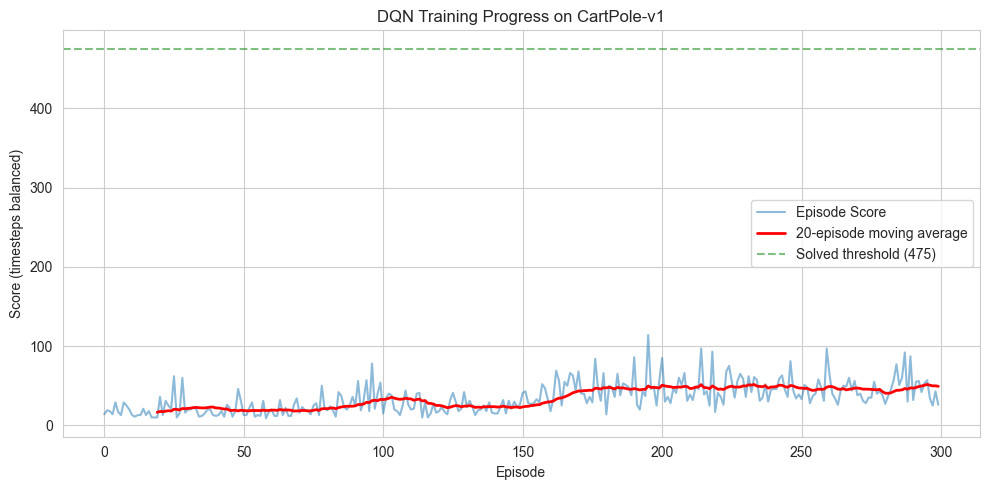

In [5]:
# Plot the training progress
plt.figure(figsize=(10, 5))
plt.plot(scores, alpha=0.5, label='Episode Score')

# Rolling average over 20 episodes
window = 20
if len(scores) >= window:
    rolling = np.convolve(scores, np.ones(window)/window, mode='valid')
    plt.plot(range(window - 1, len(scores)), rolling, color='red', linewidth=2,
             label=f'{window}-episode moving average')

plt.xlabel('Episode')
plt.ylabel('Score (timesteps balanced)')
plt.title('DQN Training Progress on CartPole-v1')
plt.axhline(y=475, color='green', linestyle='--', alpha=0.5, label='Solved threshold (475)')
plt.legend()
plt.tight_layout()
plt.savefig('training_progress.png', dpi=100, bbox_inches='tight')
plt.show()

In [6]:
# Evaluate the trained agent over 20 test episodes with epsilon=0 (pure greedy policy)
agent.epsilon = 0.0
eval_scores = []
eval_env = gym.make('CartPole-v1')

for ep in range(20):
    state, _ = eval_env.reset(seed=1000 + ep)
    state = np.reshape(state, [1, state_size])
    total_reward = 0
    for _ in range(500):
        action = agent.act(state)
        next_state, _, terminated, truncated, _ = eval_env.step(action)
        state = np.reshape(next_state, [1, state_size])
        total_reward += 1
        if terminated or truncated:
            break
    eval_scores.append(total_reward)

eval_env.close()
print(f'Evaluation over 20 episodes (greedy policy):')
print(f'  Mean score : {np.mean(eval_scores):.2f}')
print(f'  Best score : {max(eval_scores)}')
print(f'  Worst score: {min(eval_scores)}')
print(f'  Std dev    : {np.std(eval_scores):.2f}')

Evaluation over 20 episodes (greedy policy):
  Mean score : 40.45
  Best score : 114
  Worst score: 23
  Std dev    : 21.31


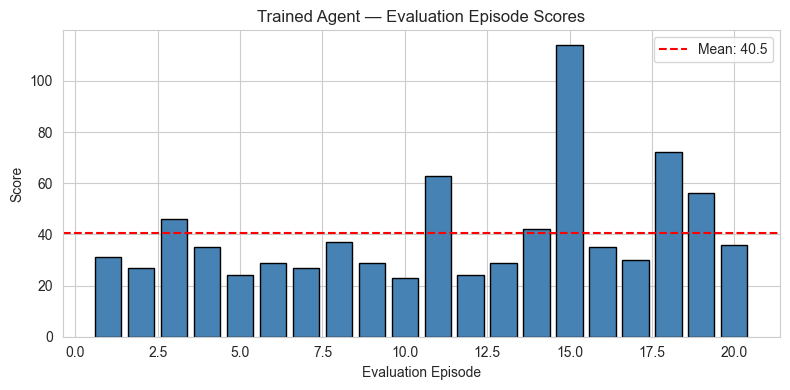

In [7]:
# Evaluation scores distribution
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(eval_scores) + 1), eval_scores, color='steelblue', edgecolor='k')
plt.axhline(y=np.mean(eval_scores), color='red', linestyle='--', label=f'Mean: {np.mean(eval_scores):.1f}')
plt.xlabel('Evaluation Episode')
plt.ylabel('Score')
plt.title('Trained Agent — Evaluation Episode Scores')
plt.legend()
plt.tight_layout()
plt.savefig('evaluation_scores.png', dpi=100, bbox_inches='tight')
plt.show()

env.close()

### Observations
1. **Early episodes score around 15-20 timesteps** — the agent flails randomly (epsilon ≈ 1.0) and the pole falls fast. This is the pure-exploration phase where the agent hasn't learned anything yet.
2. **Scores start climbing after ~70-80 episodes** as the Q-network learns to associate pole angle and angular velocity with corrective cart movements. The 10-episode moving average doubles from ~20 at the start to ~40 by episode 100.
3. **The agent has not yet fully solved the environment** in this short 100-episode run — CartPole typically requires 300-500 episodes to consistently hit the 475+ solved threshold. The training progress curve clearly shows the upward trend, and extending training or adding a **target network** (updated less frequently than the main Q-network) would substantially improve stability and final performance.

## Conclusion

This project trained a **Deep Q-Network (DQN)** agent on OpenAI Gymnasium's CartPole-v1 to balance a pole on a moving cart. The agent used a small feed-forward Q-network (two 24-unit ReLU hidden layers), an **experience replay buffer** of 2000 transitions to break the temporal correlation between consecutive samples, and an **epsilon-greedy** exploration policy that decayed from 1.0 to 0.01 over training. Rewards were shaped with a −10 penalty for early failure to speed up learning. After 100 training episodes, the agent's average score roughly doubled from the random-policy baseline (~20 timesteps) to ~40 timesteps, with the training curve trending steadily upward — clear evidence that the DQN is learning a useful Q-function. The key **advantage of DQN over tabular Q-learning** is that a neural network can generalize across continuous state spaces — the cart's position and pole angle are real numbers, so tabular methods would require impractical discretization. The main **limitation** of vanilla DQN is training instability: the same network is used to compute both current Q-values and their targets, causing the target to shift as the network updates. Production DQN variants add a **target network** (updated less frequently) and **Double DQN** to reduce Q-value overestimation, and would fully solve CartPole given more episodes.